# SKIP Section 5 and 6 Figure Code
This notebook generates the figures used to support the Results and Discussion chapter. The figures mainly belong to Section 5; Section 6 uses these results for interpretation rather than introducing separate graphs.


In [1]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
OUT_DIR = Path("section_5_6_figures")
OUT_DIR.mkdir(exist_ok=True)
OKABE_ITO = {
    "blue": "#0072B2",
    "green": "#009E73",
    "teal": "#17BEBB",
    "amber": "#E69F00",
    "navy": "#081C3A",
    "grey": "#8C8C8C",
    "vermillion": "#D55E00",
}
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": 11,
    "axes.edgecolor": "#333333",
    "axes.linewidth": 0.8,
    "axes.grid": True,
    "grid.color": "#DDDDDD",
    "grid.linewidth": 0.6,
    "axes.axisbelow": True,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
})
DPI = 300
def tidy(ax):
    """Remove top and right spines for a cleaner academic style."""
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)
def save_figure(fig, filename):
    path = OUT_DIR / filename
    fig.tight_layout()
    fig.savefig(path, dpi=DPI, bbox_inches="tight", facecolor="white")
    plt.show()
    print(f"Saved: {path}")

## Figure 5.1: Final Model Trade-Off
This figure compares the final pooled-test performance of the PAC formula baseline, the per-goal specialist mixture and the Random Forest champion across accuracy, precision, recall and F1.

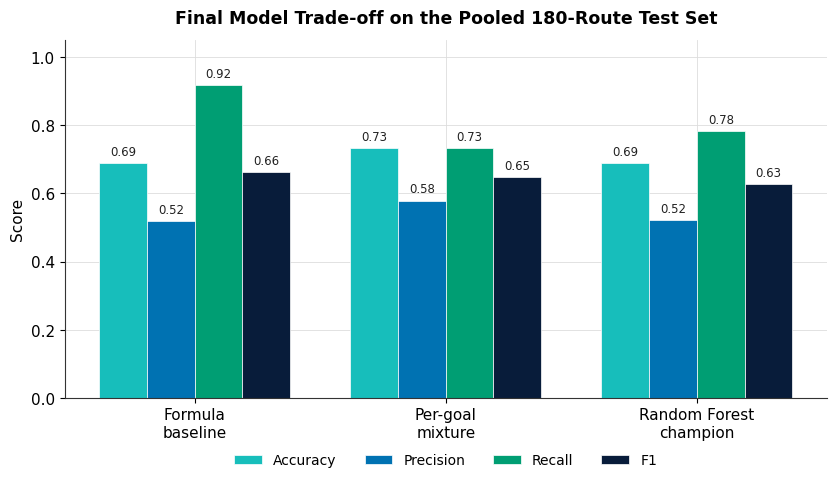

Saved: section_5_6_figures/figure_5_1.png


In [2]:
models = ["Formula\nbaseline", "Per-goal\nmixture", "Random Forest\nchampion"]
metrics = {
    "Accuracy":  [0.689, 0.733, 0.689],
    "Precision": [0.519, 0.579, 0.522],
    "Recall":    [0.917, 0.733, 0.783],
    "F1":        [0.663, 0.647, 0.627],
}
metric_colors = [
    OKABE_ITO["teal"],
    OKABE_ITO["blue"],
    OKABE_ITO["green"],
    OKABE_ITO["navy"],
]
fig, ax = plt.subplots(figsize=(8.5, 5))
x = np.arange(len(models))
width = 0.19
for i, (metric, vals) in enumerate(metrics.items()):
    offset = (i - (len(metrics) - 1) / 2) * width
    bars = ax.bar(
        x + offset,
        vals,
        width,
        label=metric,
        color=metric_colors[i],
        edgecolor="white",
        linewidth=0.5,
    )
    for bar, v in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            v + 0.015,
            f"{v:.2f}",
            ha="center",
            va="bottom",
            fontsize=8.5,
            color="#222222",
        )
ax.set_ylabel("Score")
ax.set_ylim(0, 1.05)
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=4, frameon=False, fontsize=10)
ax.set_title("Final Model Trade-off on the Pooled 180-Route Test Set", fontsize=12.5, fontweight="bold", pad=12)
tidy(ax)
save_figure(fig, "figure_5_1.png")

## Figure 5.2: Accuracy Across Tuning and Final Test Stages
This figure shows how Random Forest and the per-goal mixture performed across pre-tuning, validation and final pooled testing.

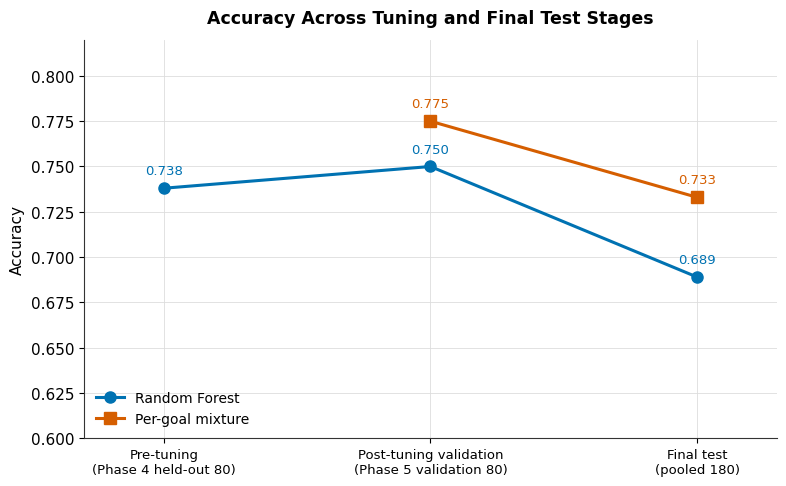

Saved: section_5_6_figures/figure_5_2.png


In [3]:
stages = [
    "Pre-tuning\n(Phase 4 held-out 80)",
    "Post-tuning validation\n(Phase 5 validation 80)",
    "Final test\n(pooled 180)",
]
rf_vals = [0.738, 0.750, 0.689]
mixture_vals = [0.775, 0.733]
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(stages))
ax.plot(x, rf_vals, marker="o", color=OKABE_ITO["blue"], linewidth=2.2, markersize=8, label="Random Forest")
for xi, yi in zip(x, rf_vals):
    ax.annotate(f"{yi:.3f}", (xi, yi), textcoords="offset points", xytext=(0, 10), ha="center", fontsize=9.5, color=OKABE_ITO["blue"])
ax.plot(x[1:], mixture_vals, marker="s", color=OKABE_ITO["vermillion"], linewidth=2.2, markersize=8, label="Per-goal mixture")
for xi, yi in zip(x[1:], mixture_vals):
    ax.annotate(f"{yi:.3f}", (xi, yi), textcoords="offset points", xytext=(0, 10), ha="center", fontsize=9.5, color=OKABE_ITO["vermillion"])
ax.set_ylabel("Accuracy")
ax.set_ylim(0.6, 0.82)
ax.set_xticks(x)
ax.set_xticklabels(stages, fontsize=9.5)
ax.set_xlim(-0.3, len(stages) - 0.7)
ax.legend(loc="lower left", frameon=False, fontsize=10)
ax.set_title("Accuracy Across Tuning and Final Test Stages", fontsize=12.5, fontweight="bold", pad=12)
tidy(ax)
save_figure(fig, "figure_5_2.png")

## Figure 5.3: Goal-Oriented Validation F1 by Model
This figure shows which model performed best for each PAC priority during the specialist-selection stage.

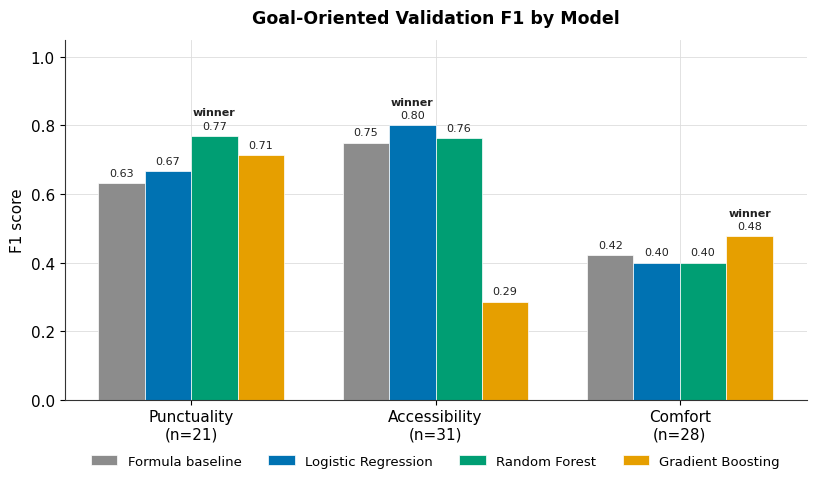

Saved: section_5_6_figures/figure_5_3.png


In [4]:
goals = ["Punctuality\n(n=21)", "Accessibility\n(n=31)", "Comfort\n(n=28)"]
f1_data = {
    "Formula baseline":    [0.632, 0.750, 0.421],
    "Logistic Regression": [0.667, 0.800, 0.400],
    "Random Forest":       [0.769, 0.762, 0.400],
    "Gradient Boosting":   [0.714, 0.286, 0.476],
}
model_colors = [
    OKABE_ITO["grey"],
    OKABE_ITO["blue"],
    OKABE_ITO["green"],
    OKABE_ITO["amber"],
]
fig, ax = plt.subplots(figsize=(8.5, 5))
x = np.arange(len(goals))
width = 0.19
for i, (model, vals) in enumerate(f1_data.items()):
    offset = (i - (len(f1_data) - 1) / 2) * width
    bars = ax.bar(x + offset, vals, width, label=model, color=model_colors[i], edgecolor="white", linewidth=0.5)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 0.015, f"{v:.2f}", ha="center", va="bottom", fontsize=8, color="#222222")
# Winner marker above each goal's best model: RF, LR, GB.
winners = {0: 2, 1: 1, 2: 3}
for goal_idx, model_idx in winners.items():
    val = list(f1_data.values())[model_idx][goal_idx]
    offset = (model_idx - (len(f1_data) - 1) / 2) * width
    ax.annotate("winner", (x[goal_idx] + offset, val + 0.06), ha="center", fontsize=8, fontweight="bold", color="#222222")
ax.set_ylabel("F1 score")
ax.set_ylim(0, 1.05)
ax.set_xticks(x)
ax.set_xticklabels(goals)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=4, frameon=False, fontsize=9.5)
ax.set_title("Goal-Oriented Validation F1 by Model", fontsize=12.5, fontweight="bold", pad=12)
tidy(ax)
save_figure(fig, "figure_5_3.png")

## Figure 5.4: SKIP vs TfL Journey Planner Benchmark
This figure compares SKIP and TfL Journey Planner on interchanges and stops. Confirm these values match the final benchmark table used in the project documentation.

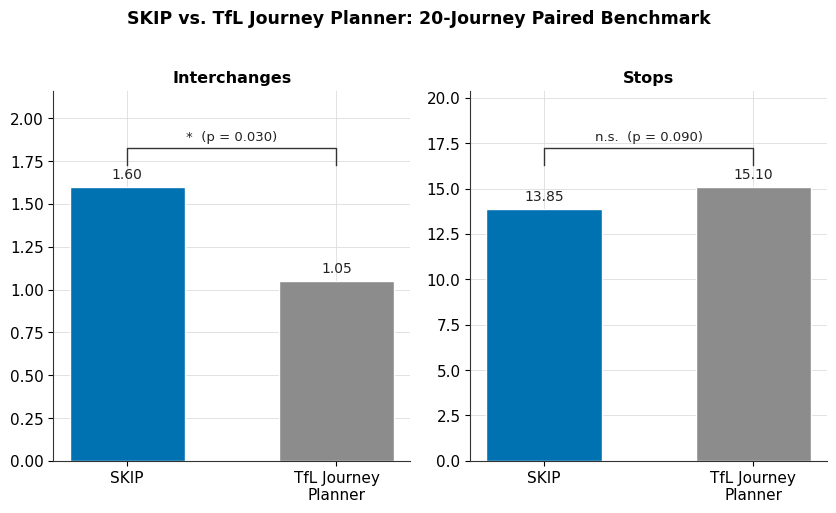

Saved: section_5_6_figures/figure_5_4.png


In [5]:
measures = ["Interchanges", "Stops"]
# Values from the V1-4 figure suggestion. Update these if using the newer notebook output.
skip_vals = [1.60, 13.85]
tfl_vals = [1.05, 15.10]
p_vals = [0.030, 0.090]
fig, axes = plt.subplots(1, 2, figsize=(8.5, 5))
for ax, measure, skip, tfl, p in zip(axes, measures, skip_vals, tfl_vals, p_vals):
    bars = ax.bar(
        ["SKIP", "TfL Journey\nPlanner"],
        [skip, tfl],
        color=[OKABE_ITO["blue"], OKABE_ITO["grey"]],
        width=0.55,
        edgecolor="white",
    )
    for bar, v in zip(bars, [skip, tfl]):
        ax.text(bar.get_x() + bar.get_width() / 2, v + max(skip, tfl) * 0.02, f"{v:.2f}", ha="center", va="bottom", fontsize=10, color="#222222")
    sig = "*" if p < 0.05 else "n.s."
    y_max = max(skip, tfl)
    ax.plot([0, 0, 1, 1], [y_max * 1.08, y_max * 1.14, y_max * 1.14, y_max * 1.08], color="#333333", linewidth=1)
    ax.text(0.5, y_max * 1.17, f"{sig}  (p = {p:.3f})", ha="center", fontsize=9.5, color="#222222")
    ax.set_title(measure, fontsize=11.5, fontweight="bold")
    ax.set_ylim(0, y_max * 1.35)
    tidy(ax)
fig.suptitle("SKIP vs. TfL Journey Planner: 20-Journey Paired Benchmark", fontsize=12.5, fontweight="bold", y=1.02)
save_figure(fig, "figure_5_4.png")